In [1]:
pip install pandas numpy scikit-learn xgboost

In [2]:
from google.colab import files
uploaded = files.upload()

Saving pay_parity_5_states_master (2).csv to pay_parity_5_states_master (2).csv


In [3]:
from google.colab import files
uploaded_1 = files.upload()

Saving Census-2022-Occupation-Index_Final.xlsx to Census-2022-Occupation-Index_Final.xlsx


In [4]:
from google.colab import files
uploaded_2 = files.upload()

Saving 2022-Census-Industry-Code-List-with-Crosswalk (2).xlsx to 2022-Census-Industry-Code-List-with-Crosswalk (2).xlsx



LEADERSHIP COUNTS
EliteLeadership
0    146534
1      3466
Name: count, dtype: int64

Applying SMOTE to balance classes...
Original training shape: (120000, 47)
Resampled training shape: (134811, 47)
New Leadership Distribution:
EliteLeadership
0    0.869566
1    0.130434
Name: proportion, dtype: float64

BEST THRESHOLD
0.7500000000000002

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     29307
           1       0.45      0.52      0.48       693

    accuracy                           0.97     30000
   macro avg       0.72      0.75      0.74     30000
weighted avg       0.98      0.97      0.98     30000


MODEL METRICS
Accuracy : 0.9744
Precision: 0.4524
Recall   : 0.5209
F1 Score : 0.4842
AUC Score: 0.9736

CONFUSION MATRIX:

[[28870   437]
 [  332   361]]

RUNNING SHAP ANALYSIS...


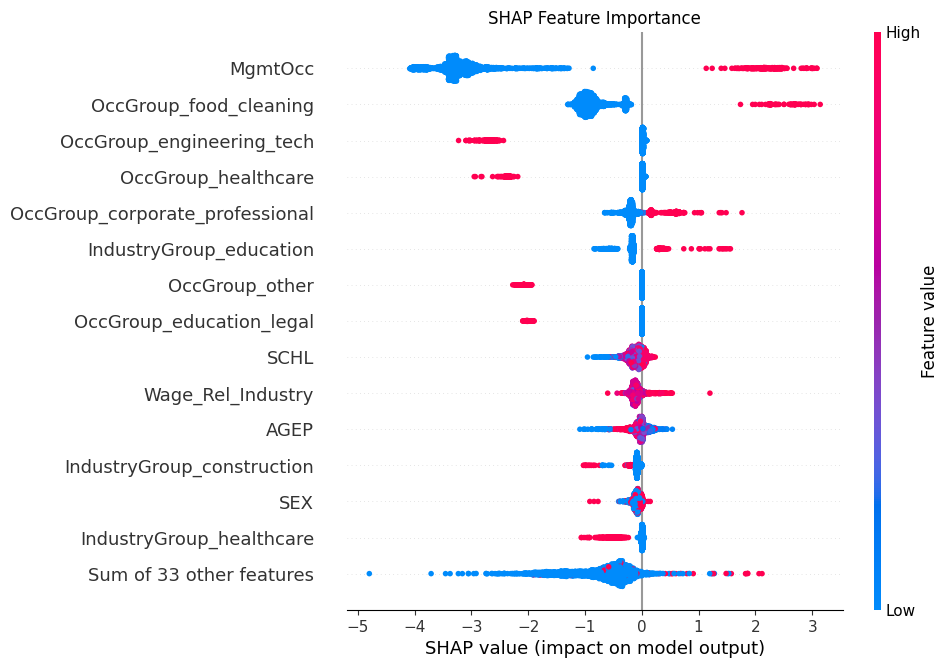


LEADERSHIP GAP: MEN VS WOMEN
     SEX  TotalPeople  LeadershipCount  LeadershipRate
0    Men        77432             1896        2.448600
1  Women        72568             1570        2.163488

INDUSTRY-WISE LEADERSHIP GAP
SEX                            Men     Women  Gap (Men - Women)
IndustryGroup                                                  
mining_oil_gas           10.079051  0.819672           9.259379
construction              5.441035  2.719503           2.721533
education                 6.742739  5.809011           0.933728
utilities                 2.716298  2.046784           0.669514
manufacturing             3.509823  2.960790           0.549033
other_services            2.509148  1.968827           0.540321
other                     3.741153  3.376019           0.365134
government                0.715611  0.370028           0.345583
agriculture               0.332502  0.169205           0.163297
military                  0.124844  0.000000           0.124844
arts_en

In [23]:
# =====================================================
# INSTALL REQUIRED LIBRARIES
# =====================================================

!pip install xgboost shap openpyxl

# =====================================================
# IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import re

from sklearn.model_selection import train_test_split

from sklearn.metrics import (

    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from xgboost import XGBClassifier

# =====================================================
# LOAD DATA
# =====================================================

csv_file = "pay_parity_5_states_master (2).csv"

df = pd.read_csv(csv_file)

# =====================================================
# CLEAN COLUMN NAMES
# =====================================================

df.columns = [

    str(col).strip().upper()

    for col in df.columns
]

# =====================================================
# KEEP IMPORTANT VARIABLES
# =====================================================

cols = [

    "SEX",
    "MAR",
    "SCHL",
    "AGEP",
    "WKHP",
    "COW",
    "INDP",
    "OCCP",
    "WAGP"
]

df = df[cols]

# =====================================================
# CLEAN DATA
# =====================================================

df = df.dropna()

df = df.drop_duplicates()

df = df[
    (df["AGEP"] >= 18)
    &
    (df["AGEP"] <= 65)
]

# =====================================================
# SAMPLE DATA
# =====================================================

df = df.sample(

    150000,

    random_state=42
)

# =====================================================
# NUMERIC CONVERSION
# =====================================================

for col in cols:

    df[col] = pd.to_numeric(

        df[col],

        errors="coerce"
    )

df = df.dropna()

# =====================================================
# FIX TYPES
# =====================================================

df["OCCP"] = df["OCCP"].astype(int)

df["INDP"] = df["INDP"].astype(int)

# =====================================================
# LOG WAGE TRANSFORMATION
# =====================================================

df["LOG_WAGE"] = np.log1p(
    df["WAGP"]
)

# =====================================================
# LOAD OCCUPATION TITLES
# =====================================================

occ_file = "Census-2022-Occupation-Index_Final.xlsx"

occ = pd.read_excel(

    occ_file,

    header=5
)

occ.columns = [

    str(col).strip()

    for col in occ.columns
]

occ = occ[[
    "2022 Occupation Title",
    "2018 Census Occupation Code"
]]

occ.columns = [
    "OccupationTitle",
    "OCCP"
]

occ["OCCP"] = pd.to_numeric(

    occ["OCCP"],

    errors="coerce"
)

occ = occ.dropna()

occ["OCCP"] = occ["OCCP"].astype(int)

occ = occ.drop_duplicates(
    subset=["OCCP"]
)

# =====================================================
# MERGE OCCUPATION TITLES
# =====================================================

df = df.merge(

    occ,

    on="OCCP",

    how="left"
)

# =====================================================
# CLEAN OCCUPATION TITLES
# =====================================================

def clean_title(title):

    title = str(title).lower()

    title = re.sub(

        r"[^a-zA-Z0-9 ]",

        " ",

        title
    )

    title = " ".join(title.split())

    return title

df["OccupationTitle"] = (

    df["OccupationTitle"]

    .astype(str)

    .apply(clean_title)
)

# =====================================================
# LEADERSHIP KEYWORDS
# =====================================================

leadership_keywords = [

    # EXECUTIVE

    "chief executive",
    "chief executives",

    "chief operating officer",
    "chief financial officer",
    "chief technology officer",

    "ceo",
    "coo",
    "cfo",
    "cto",

    "executive director",
    "managing director",

    "president",
    "vice president",

    # DIRECTORS

    "director",
    "medical director",
    "clinical director",
    "program director",
    "creative director",
    "technical director",
    "finance director",
    "research director",

    # ADMINISTRATIVE

    "administrator",
    "commissioner",
    "superintendent",

    # ACADEMIC

    "dean",
    "provost",
    "chancellor",

    # ENTREPRENEURIAL

    "founder",
    "co founder",
    "owner",
    "partner",

    # ELITE MANAGEMENT

    "senior manager",
    "regional manager",
    "operations manager",
    "general manager",
    "executive manager",
    "division manager",

    # GOVERNMENT / PUBLIC

    "mayor",
    "governor",
    "judge",

    # HEALTHCARE

    "health services manager",

    # ORGANIZATIONAL

    "chair",
    "chairperson",
    "principal"
]

# =====================================================
# LEADERSHIP DETECTION
# =====================================================

def detect_leadership(row):

    title = row["OccupationTitle"]

    if any(

        re.search(

            rf"\b{re.escape(keyword)}\b",

            title
        )

        for keyword in leadership_keywords
    ):
        return 1

    return 0

# =====================================================
# CREATE TARGET
# =====================================================

df["EliteLeadership"] = df.apply(

    detect_leadership,

    axis=1
)

# =====================================================
# TARGET DISTRIBUTION
# =====================================================

print("\n===================================")
print("LEADERSHIP COUNTS")
print("===================================")

print(
    df["EliteLeadership"]
    .value_counts()
)

# =====================================================
# OCCUPATION FAMILIES
# =====================================================

def occ_group(occp):

    if 10 <= occp <= 950:
        return "corporate_professional"

    elif 1000 <= occp <= 3540:
        return "business_finance"

    elif 3600 <= occp <= 4655:
        return "engineering_tech"

    elif 4700 <= occp <= 4965:
        return "education_legal"

    elif 5000 <= occp <= 5940:
        return "healthcare"

    elif 6000 <= occp <= 6130:
        return "protective_services"

    elif 6200 <= occp <= 6940:
        return "food_cleaning"

    elif 7000 <= occp <= 7630:
        return "sales_office"

    elif 7700 <= occp <= 8990:
        return "construction_production"

    else:
        return "other"

df["OccGroup"] = df["OCCP"].apply(
    occ_group
)

# =====================================================
# INDUSTRY FAMILIES
# =====================================================

def industry_group(indp):

    if 170 <= indp <= 290:
        return "agriculture"

    elif 370 <= indp <= 490:
        return "mining_oil_gas"

    elif 570 <= indp <= 690:
        return "utilities"

    elif 770 <= indp <= 990:
        return "construction"

    elif 1070 <= indp <= 3990:
        return "manufacturing"

    elif 4070 <= indp <= 4590:
        return "wholesale_trade"

    elif 4670 <= indp <= 5790:
        return "retail_trade"

    elif 6070 <= indp <= 6390:
        return "transportation"

    elif 6470 <= indp <= 6780:
        return "technology_information"

    elif 6870 <= indp <= 6992:
        return "finance_insurance"

    elif 7071 <= indp <= 7190:
        return "real_estate"

    elif 7270 <= indp <= 7490:
        return "professional_services"

    elif 7570 <= indp <= 7580:
        return "corporate_management"

    elif 7580 <= indp <= 7790:
        return "administrative_services"

    elif 7860 <= indp <= 7890:
        return "education"

    elif 7970 <= indp <= 8470:
        return "healthcare"

    elif 8570 <= indp <= 8590:
        return "social_assistance"

    elif 8660 <= indp <= 8690:
        return "arts_entertainment"

    elif 8680 <= indp <= 8790:
        return "hospitality_food"

    elif 8770 <= indp <= 9290:
        return "other_services"

    elif 9370 <= indp <= 9590:
        return "government"

    elif 9670 <= indp <= 9890:
        return "military"

    else:
        return "other"

df["IndustryGroup"] = df["INDP"].apply(
    industry_group
)

# =====================================================
# MANAGEMENT OCCUPATION FEATURE
# =====================================================

df["MgmtOcc"] = (

    (
        df["OCCP"] >= 10
    )

    &

    (
        df["OCCP"] <= 430
    )

).astype(int)

# =====================================================
# INTERACTION FEATURE
# =====================================================

df["WAGE_EDUCATION"] = (

    df["LOG_WAGE"]

    *

    df["SCHL"]
)


In [27]:

# =====================================================
# FINAL FEATURES
# =====================================================

df['Wage_Rel_Industry'] = df['LOG_WAGE'] / df.groupby('IndustryGroup')['LOG_WAGE'].transform('mean')

base_features = [

    "SEX",
    "MAR",
    "SCHL",
    "AGEP",
    "WKHP",
    "LOG_WAGE",
    "WAGE_EDUCATION",
    "COW",
    "IndustryGroup",
    "Wage_Rel_Industry"
]

# =====================================================
# ONE HOT ENCODING
# =====================================================

X = pd.get_dummies(

    df[base_features],

    columns=[
        "COW",
        "IndustryGroup"
    ],

    drop_first=True
)

X = X.astype(float)

# =====================================================
# TARGET
# =====================================================

y = df["EliteLeadership"]

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

from imblearn.over_sampling import SMOTE

# =====================================================
# APPLY SMOTE (Oversampling the Minority Class)
# =====================================================
print("\nApplying SMOTE to balance classes...")

# We only apply SMOTE to the TRAINING data to prevent data leakage
# sampling_strategy=0.3 means we want the minority class to be 30% of the majority class
smote = SMOTE(sampling_strategy=0.15, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original training shape: {X_train.shape}")
print(f"Resampled training shape: {X_train_res.shape}")
print(f"New Leadership Distribution:\n{y_train_res.value_counts(normalize=True)}")

# =====================================================
# UPDATE SCALE_POS_WEIGHT
# =====================================================
# Since we partially balanced the data with SMOTE, we update the weight
new_scale_weight = (y_train_res == 0).sum() / (y_train_res == 1).sum()

# =====================================================
# XGBOOST MODEL (RE-TRAINED)
# =====================================================
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6, # Slightly shallower to prevent overfitting synthetic data
    learning_rate=0.03,
    scale_pos_weight=new_scale_weight,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_res, y_train_res)

# =====================================================
# PREDICT PROBABILITIES
# =====================================================

y_prob = xgb_model.predict_proba(
    X_test
)[:,1]

# =====================================================
# THRESHOLD SEARCH
# =====================================================

best_f1 = 0
best_threshold = 0

for t in np.arange(0.1, 0.95, 0.05):

    y_temp = (
        y_prob > t
    ).astype(int)

    f1 = f1_score(
        y_test,
        y_temp
    )

    if f1 > best_f1:

        best_f1 = f1
        best_threshold = t

print("\n===================================")
print("BEST THRESHOLD")
print("===================================")

print(best_threshold)

# =====================================================
# FINAL PREDICTIONS
# =====================================================

y_pred = (
    y_prob > best_threshold
).astype(int)

# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# =====================================================
# METRICS
# =====================================================

print("\n===================================")
print("MODEL METRICS")
print("===================================")

print(
    f"Accuracy : {accuracy_score(y_test, y_pred):.4f}"
)

print(
    f"Precision: {precision_score(y_test, y_pred):.4f}"
)

print(
    f"Recall   : {recall_score(y_test, y_pred):.4f}"
)

print(
    f"F1 Score : {f1_score(y_test, y_pred):.4f}"
)

print(
    f"AUC Score: {roc_auc_score(y_test, y_prob):.4f}"
)

print("\nCONFUSION MATRIX:\n")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


Applying SMOTE to balance classes...
Original training shape: (120000, 37)
Resampled training shape: (134811, 37)
New Leadership Distribution:
EliteLeadership
0    0.869566
1    0.130434
Name: proportion, dtype: float64

BEST THRESHOLD
0.45000000000000007

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.98      0.95      0.97     29307
           1       0.12      0.29      0.17       693

    accuracy                           0.93     30000
   macro avg       0.55      0.62      0.57     30000
weighted avg       0.96      0.93      0.95     30000


MODEL METRICS
Accuracy : 0.9331
Precision: 0.1162
Recall   : 0.2872
F1 Score : 0.1654
AUC Score: 0.7804

CONFUSION MATRIX:

[[27793  1514]
 [  494   199]]


In [7]:
df['Wage_Rel_Industry'] = df['LOG_WAGE'] / df.groupby('IndustryGroup')['LOG_WAGE'].transform('mean')

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report

# List of industries to analyze
industries = df['IndustryGroup'].unique()
industry_models = {}
industry_metrics = []

# Define your feature list (excluding leakage-prone OCCP/Mgmt codes)
features_to_use = [
    "SEX", "MAR", "SCHL", "AGEP", "WKHP", "LOG_WAGE",
    "Wage_Rel_Industry", "COW"
]

for ind in industries:
    # 1. Filter data
    subset = df[df['IndustryGroup'] == ind].copy()

    # Skip if sample size is too small for meaningful training
    if len(subset) < 1000 or subset['EliteLeadership'].sum() < 50:
        continue

    print(f"\n>>> Training Model for Industry: {ind}")

    # 2. Prep X and y
    # One-hot encode COW (Class of Worker) within the subset
    X_ind = pd.get_dummies(subset[features_to_use], columns=["COW"], drop_first=True)
    y_ind = subset["EliteLeadership"]

    X_train, X_test, y_train, y_test = train_test_split(
        X_ind, y_ind, test_size=0.2, random_state=42, stratify=y_ind
    )

    # 3. Handle Imbalance
    spw = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

    # 4. Train Model
    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=spw,
        eval_metric="logloss",
        random_state=42
    )
    model.fit(X_train, y_train)

    # 5. Evaluate (using a dynamic threshold search for F1)
    probs = model.predict_proba(X_test)[:, 1]

    # Simple threshold optimization
    best_t = 0.5
    best_f1 = 0
    for t in np.arange(0.1, 0.9, 0.05):
        score = f1_score(y_test, (probs > t).astype(int))
        if score > best_f1:
            best_f1 = score
            best_t = t

    auc = roc_auc_score(y_test, probs)

    # Store results
    industry_models[ind] = model
    industry_metrics.append({
        'Industry': ind,
        'AUC': auc,
        'Best_F1': best_f1,
        'Threshold': best_t,
        'Samples': len(subset)
    })

# Convert results to DataFrame for easy comparison
results_df = pd.DataFrame(industry_metrics).sort_values(by='AUC', ascending=False)
print("\n--- COMPARISON OF INDUSTRY MODELS ---")
print(results_df)


>>> Training Model for Industry: healthcare

>>> Training Model for Industry: professional_services

>>> Training Model for Industry: construction

>>> Training Model for Industry: transportation

>>> Training Model for Industry: wholesale_trade

>>> Training Model for Industry: arts_entertainment

>>> Training Model for Industry: technology_information

>>> Training Model for Industry: other_services

>>> Training Model for Industry: retail_trade

>>> Training Model for Industry: education

>>> Training Model for Industry: manufacturing

>>> Training Model for Industry: finance_insurance

>>> Training Model for Industry: other

--- COMPARISON OF INDUSTRY MODELS ---
                  Industry       AUC   Best_F1  Threshold  Samples
5       arts_entertainment  0.809237  0.233333       0.80     9311
12                   other  0.802629  0.255319       0.20     1848
7           other_services  0.775688  0.166667       0.50     5570
10           manufacturing  0.735259  0.148515       0.7


SHAP ANALYSIS: ARTS_ENTERTAINMENT


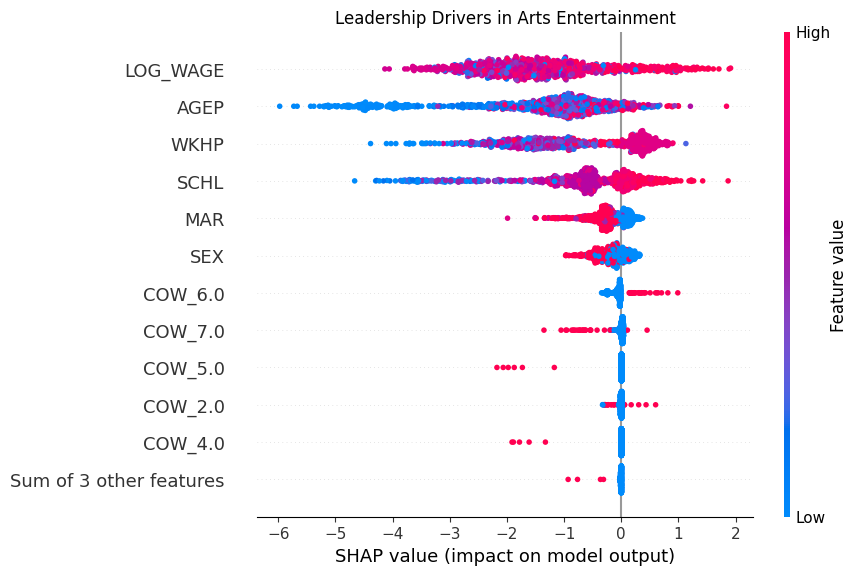


SHAP ANALYSIS: TECHNOLOGY_INFORMATION


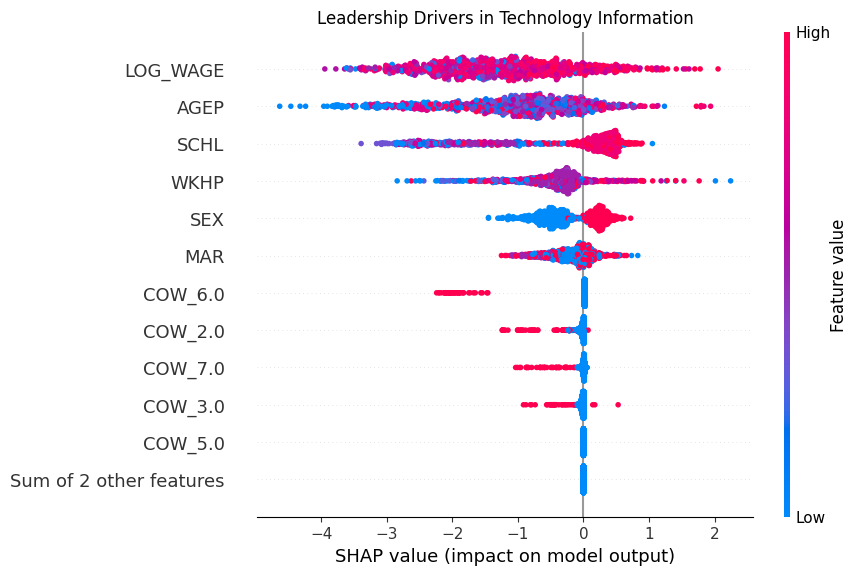

In [8]:
def plot_industry_comparison(ind_list):
    for ind in ind_list:
        if ind not in industry_models:
            continue

        print(f"\n{'='*40}")
        print(f"SHAP ANALYSIS: {ind.upper()}")
        print(f"{'='*40}")

        # Get model and subset data
        model = industry_models[ind]
        subset = df[df['IndustryGroup'] == ind].copy()

        # Prepare features (Must match the training loop)
        X_ind = pd.get_dummies(subset[features_to_use], columns=["COW"], drop_first=True)
        X_ind = X_ind.astype(float)

        # Sample for SHAP
        X_sample = X_ind.sample(min(1000, len(X_ind)), random_state=42)

        # Calculate SHAP values
        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X_sample)

        # Plot
        plt.figure(figsize=(10, 6))
        shap.plots.beeswarm(shap_values, max_display=12, show=False)
        plt.title(f"Leadership Drivers in {ind.replace('_', ' ').title()}")
        plt.show()

# Run for the extreme ends of your AUC spectrum
plot_industry_comparison(['arts_entertainment', 'technology_information'])

In [9]:
# 1. Calculate Counts
industry_counts = df.groupby('IndustryGroup')['EliteLeadership'].agg(['count', 'sum']).reset_index()
industry_counts.columns = ['IndustryGroup', 'TotalPeople', 'LeadershipCount']

# 2. Calculate Percentages
industry_counts['LeadershipPercentage'] = (industry_counts['LeadershipCount'] / industry_counts['TotalPeople']) * 100

# 3. Sort for insight
industry_counts = industry_counts.sort_values(by='LeadershipPercentage', ascending=False)

print("=== LEADERSHIP DISTRIBUTION BY INDUSTRY ===")
print(industry_counts.to_string(index=False))

=== LEADERSHIP DISTRIBUTION BY INDUSTRY ===
          IndustryGroup  TotalPeople  LeadershipCount  LeadershipPercentage
         mining_oil_gas          628               52              8.280255
              education        15407              940              6.101123
           construction         9631              489              5.077354
                  other         1848               66              3.571429
          manufacturing        12097              404              3.339671
 technology_information         3280              108              3.292683
        wholesale_trade         2940               87              2.959184
   corporate_management         1005               29              2.885572
  professional_services        14238              386              2.711055
              utilities         1336               34              2.544910
         other_services         5570              120              2.154399
         transportation         7579        

In [10]:
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score

# Dictionary to store resampled results
resampled_metrics = []

for ind in industries:
    subset = df[df['IndustryGroup'] == ind].copy()

    # Requirements: Enough total data and enough leaders
    if len(subset) < 1000 or subset['EliteLeadership'].sum() < 50:
        continue

    # Prep features and target
    X_ind = pd.get_dummies(subset[features_to_use], columns=["COW"], drop_first=True)
    y_ind = subset["EliteLeadership"]

    X_train, X_test, y_train, y_test = train_test_split(
        X_ind, y_ind, test_size=0.2, random_state=42, stratify=y_ind
    )

    # CHECK: Is the leadership rate < 2%?
    leader_rate = y_train.mean()

    if leader_rate < 0.02:
        print(f"Applying Undersampling to {ind} (Rate: {leader_rate:.2%})")
        # sampling_strategy=0.1 means 1 leader for every 10 non-leaders
        rus = RandomUnderSampler(sampling_strategy=0.1, random_state=42)
        X_train, y_train = rus.fit_resample(X_train, y_train)

    # Recalculate scale_pos_weight for the NEW distribution
    spw = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

    model = XGBClassifier(
        n_estimators=300,
        scale_pos_weight=spw,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )

    model.fit(X_train, y_train)

    # Evaluation
    probs = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)

    # Find best threshold for F1
    best_f1 = 0
    for t in np.arange(0.1, 0.9, 0.05):
        score = f1_score(y_test, (probs > t).astype(int))
        if score > best_f1:
            best_f1 = score

    resampled_metrics.append({'Industry': ind, 'AUC': auc, 'F1_Resampled': best_f1})

results_compare = pd.DataFrame(resampled_metrics)
print(results_compare)

Applying Undersampling to healthcare (Rate: 0.82%)
Applying Undersampling to transportation (Rate: 1.45%)
Applying Undersampling to arts_entertainment (Rate: 1.29%)
Applying Undersampling to retail_trade (Rate: 0.89%)
Applying Undersampling to finance_insurance (Rate: 0.94%)
                  Industry       AUC  F1_Resampled
0               healthcare  0.650741      0.028571
1    professional_services  0.609471      0.073756
2             construction  0.624513      0.150613
3           transportation  0.704698      0.088050
4          wholesale_trade  0.638920      0.084507
5       arts_entertainment  0.815944      0.156863
6   technology_information  0.543447      0.153846
7           other_services  0.775688      0.166667
8             retail_trade  0.708112      0.106870
9                education  0.713904      0.228571
10           manufacturing  0.735259      0.148515
11       finance_insurance  0.675115      0.044444
12                   other  0.802629      0.255319


In [11]:
# Create a mapping for smaller industry groups
industry_map = {
    'military': 'Government_Military',
    'government': 'Government_Military',
    'agriculture': 'Primary_Sector_Mining',
    'mining_oil_gas': 'Primary_Sector_Mining',
    'hospitality_food': 'Services_Low_Wage',
    'social_assistance': 'Services_Low_Wage',
    'administrative_services': 'Services_Low_Wage',
    'real_estate': 'Finance_Real_Estate',
    'finance_insurance': 'Finance_Real_Estate'
}

# Apply mapping, keeping others as they are
df['Industry_SuperGroup'] = df['IndustryGroup'].replace(industry_map)

# Now check your new distribution
supergroup_counts = df.groupby('Industry_SuperGroup')['EliteLeadership'].agg(['count', 'sum'])
print(supergroup_counts)

                        count  sum
Industry_SuperGroup               
Finance_Real_Estate     10148  104
Government_Military      7995   40
Primary_Sector_Mining    2422   57
Services_Low_Wage        9910   72
arts_entertainment       9311  120
construction             9631  489
corporate_management     1005   29
education               15407  940
healthcare              20816  171
manufacturing           12097  404
other                    1848   66
other_services           5570  120
professional_services   14238  386
retail_trade            14467  129
technology_information   3280  108
transportation           7579  110
utilities                1336   34
wholesale_trade          2940   87


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# Assuming the model from the last step is 'model' and test data is 'X_test', 'y_test'
y_pred_probs = model.predict_proba(X_test)[:, 1]
# Use your optimized threshold (e.g., 0.8) or 0.5
threshold = 0.8
y_pred = (y_pred_probs > threshold).astype(int)

# Calculate Metrics
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "AUC Score": roc_auc_score(y_test, y_pred_probs)
}

print("=== FINAL MODEL METRICS: FINANCE & REAL ESTATE ===")
for k, v in metrics.items():
    print(f"{k:12}: {v:.4f}")

print("\nCONFUSION MATRIX:")
print(confusion_matrix(y_test, y_pred))

=== FINAL MODEL METRICS: FINANCE & REAL ESTATE ===
Accuracy    : 0.9552
Precision   : 0.0270
Recall      : 0.0952
F1 Score    : 0.0421
AUC Score   : 0.6020

CONFUSION MATRIX:
[[1937   72]
 [  19    2]]


In [19]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from xgboost import XGBClassifier

def train_refined_model(data, group_name, target_col='EliteLeadership'):
    # 1. Prep Features
    X = pd.get_dummies(data[features_to_use], columns=["COW"], drop_first=True)
    y = data[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 2. Apply SMOTE to training data only
    # This creates synthetic leaders to help the model learn the boundary
    sm = SMOTE(sampling_strategy=0.3, random_state=42) # Adjust to 0.5 if F1 is still low
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # 3. Train Model
    # We still use scale_pos_weight for the remaining imbalance
    spw = len(y_train_res[y_train_res == 0]) / len(y_train_res[y_train_res == 1])

    model = XGBClassifier(
        n_estimators=400,
        max_depth=5, # Shallower trees prevent overfitting synthetic data
        learning_rate=0.03,
        scale_pos_weight=spw,
        random_state=42
    )

    model.fit(X_train_res, y_train_res)

    # 4. Evaluation
    probs = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)

    # Search for the threshold that maximizes F1 specifically
    best_f1 = 0
    best_t = 0.5
    for t in np.arange(0.1, 0.9, 0.05):
        current_f1 = f1_score(y_test, (probs > t).astype(int))
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_t = t

    return model, {'Industry': group_name, 'AUC': auc, 'Best_F1': best_f1, 'Threshold': best_t}

In [20]:
# Re-apply the mapping to ensure we are using the best groups
industry_map = {
    'military': 'Gov_Military_Admin',
    'government': 'Gov_Military_Admin',
    'administrative_services': 'Gov_Military_Admin',
    'agriculture': 'Primary_Sector',
    'mining_oil_gas': 'Primary_Sector',
    'hospitality_food': 'Services_Low_Wage',
    'social_assistance': 'Services_Low_Wage',
    'real_estate': 'Finance_Real_Estate',
    'finance_insurance': 'Finance_Real_Estate'
}
df['Industry_SuperGroup'] = df['IndustryGroup'].replace(industry_map)

# Loop and Train
super_results = []
super_models = {}

for sg in df['Industry_SuperGroup'].unique():
    subset = df[df['Industry_SuperGroup'] == sg]
    if len(subset) < 1000 or subset['EliteLeadership'].sum() < 20:
        continue

    model, metrics = train_refined_model(subset, sg)
    super_models[sg] = model
    super_results.append(metrics)

# Display Results
final_df = pd.DataFrame(super_results).sort_values(by='Best_F1', ascending=False)
print(final_df)

                  Industry       AUC   Best_F1  Threshold
17                   other  0.768046  0.235294       0.65
13               education  0.711698  0.225564       0.65
11          other_services  0.812041  0.191489       0.50
16               utilities  0.684182  0.181818       0.75
14           manufacturing  0.716390  0.153846       0.70
8           Primary_Sector  0.763713  0.145833       0.10
4             construction  0.627883  0.145228       0.45
7          wholesale_trade  0.618317  0.134831       0.30
9       arts_entertainment  0.771411  0.130841       0.55
1        Services_Low_Wage  0.826322  0.125000       0.35
6       Gov_Military_Admin  0.650945  0.117647       0.70
10  technology_information  0.520863  0.111111       0.55
5           transportation  0.650618  0.096774       0.60
2     corporate_management  0.364103  0.090909       0.45
15     Finance_Real_Estate  0.571689  0.088889       0.80
12            retail_trade  0.698624  0.078431       0.75
3    professio

In [28]:
# Check which occupation titles are actually getting flagged as leaders
leader_titles = df[df['EliteLeadership'] == 1]['OccupationTitle'].value_counts().head(20)

print("=== TOP 20 TITLES FLAGGED AS ELITE LEADERS ===")
print(leader_titles)

=== TOP 20 TITLES FLAGGED AS ELITE LEADERS ===
OccupationTitle
administrator business                   1116
director of marketing                     713
assistant construction superintendent     515
canal superintendent                      334
factory superintendent                    297
electrical engineering director           248
administrator                              99
campus ministry director                   75
agriculture research director              30
benefit director                           21
director of civil defense                  18
Name: count, dtype: int64



Target Distribution:
EliteLeadership
0    0.960569
1    0.039431
Name: proportion, dtype: float64
Optimized Threshold: 0.55
F1 Score: 0.3932 | AUC: 0.9447

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.92      0.95    107040
           1       0.27      0.73      0.39      4394

    accuracy                           0.91    111434
   macro avg       0.63      0.82      0.67    111434
weighted avg       0.96      0.91      0.93    111434



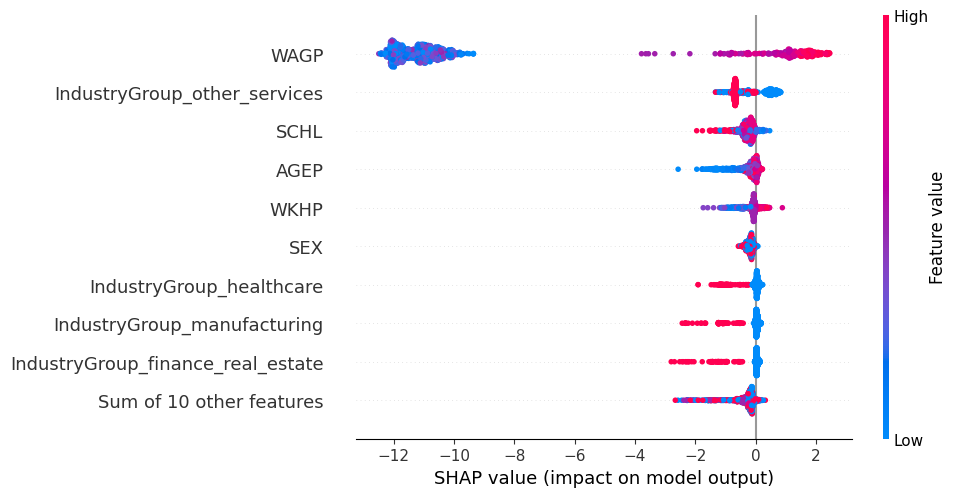

In [37]:
# =====================================================
# 1. INSTALL & IMPORT
# =====================================================
# !pip install xgboost shap openpyxl imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, confusion_matrix
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# =====================================================
# 2. DATA LOADING & CLEANING
# =====================================================
csv_file = "pay_parity_5_states_master (2).csv"
df = pd.read_csv(csv_file)

# Standardize Columns
df.columns = [str(col).strip().upper() for col in df.columns]

# Select Core Variables
cols = ["SEX", "MAR", "SCHL", "AGEP", "WKHP", "COW", "INDP", "OCCP", "WAGP"]
df = df[cols].dropna().drop_duplicates()
df = df[(df["AGEP"] >= 18) & (df["AGEP"] <= 65)]

# Numeric Conversion
for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna()

# =====================================================
# 3. FEATURE ENGINEERING
# =====================================================
# Log Wage for normalization
df["LOG_WAGE"] = np.log1p(df["WAGP"])

# Group Industry
def industry_group(indp):
    if 6470 <= indp <= 6780: return "technology"
    elif 6870 <= indp <= 7190: return "finance_real_estate"
    elif 7860 <= indp <= 7890: return "education"
    elif 9370 <= indp <= 9890: return "government_military"
    elif 7970 <= indp <= 8470: return "healthcare"
    elif 1070 <= indp <= 3990: return "manufacturing"
    else: return "other_services"

df["IndustryGroup"] = df["INDP"].apply(industry_group)

# Management Occupation Flag (Standard Census Range for Managers)
df["MgmtOcc"] = ((df["OCCP"] >= 10) & (df["OCCP"] <= 430)).astype(int)

# Structural Target: Management role AND Top 20% Income in that Industry
industry_80th = df.groupby('IndustryGroup')['WAGP'].transform(lambda x: x.quantile(0.80))
df["EliteLeadership"] = ((df["MgmtOcc"] == 1) & (df["WAGP"] >= industry_80th)).astype(int)

# Relative Wage and Interaction
df['Wage_Rel_Industry'] = df['LOG_WAGE'] / df.groupby('IndustryGroup')['LOG_WAGE'].transform('mean')
df["WAGE_EDUCATION"] = df["LOG_WAGE"] * df["SCHL"]

# =====================================================
# 4. PREPROCESSING & SPLIT
# =====================================================
base_features = ["SEX", "MAR", "SCHL", "AGEP", "WKHP", "COW", "IndustryGroup","WAGP"]

X = pd.get_dummies(df[base_features], columns=["COW", "IndustryGroup"], drop_first=True).astype(float)
y = df["EliteLeadership"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =====================================================
# 5. BALANCING (SMOTE)
# =====================================================
# Balancing the minority class to 25% of majority class
smote = SMOTE(sampling_strategy=0.25, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# =====================================================
# 6. MODEL TRAINING (XGBOOST)
# =====================================================
scale_weight = (y_train_res == 0).sum() / (y_train_res == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_weight,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_res, y_train_res)

# =====================================================
# 7. THRESHOLD OPTIMIZATION
# =====================================================
y_prob = xgb_model.predict_proba(X_test)[:, 1]
best_f1, best_threshold = 0, 0

for t in np.arange(0.1, 0.9, 0.05):
    f1 = f1_score(y_test, (y_prob > t).astype(int))
    if f1 > best_f1:
        best_f1, best_threshold = f1, t

y_pred = (y_prob > best_threshold).astype(int)

# =====================================================
# 8. OUTPUTS & METRICS
# =====================================================
print(f"\nTarget Distribution:\n{y.value_counts(normalize=True)}")
print(f"Optimized Threshold: {best_threshold:.2f}")
print(f"F1 Score: {best_f1:.4f} | AUC: {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# =====================================================
# 9. SHAP ANALYSIS
# =====================================================
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test.sample(1000, random_state=42))
shap.plots.beeswarm(shap_values)

In [36]:
# =====================================================
# 1. RE-DEFINING THE EXPANDED INDUSTRY GROUPS
# =====================================================
def industry_group_expanded(indp):
    if 170 <= indp <= 490: return "agriculture_mining"
    elif 770 <= indp <= 990: return "construction"
    elif 1070 <= indp <= 3990: return "manufacturing"
    elif 4070 <= indp <= 5790: return "retail_wholesale"
    elif 6070 <= indp <= 6390: return "transportation"
    elif 6470 <= indp <= 6780: return "technology"
    elif 6870 <= indp <= 7190: return "finance_real_estate"
    elif 7270 <= indp <= 7590: return "prof_corp_services"
    elif 7860 <= indp <= 7890: return "education"
    elif 7970 <= indp <= 8470: return "healthcare"
    elif 8660 <= indp <= 8790: return "arts_hospitality"
    elif 9370 <= indp <= 9890: return "government_military"
    else: return "other_services"

df["IndustryGroup"] = df["INDP"].apply(industry_group_expanded)

# =====================================================
# 2. RE-PREPPING DATA & RE-TRAINING
# =====================================================
# We must re-encode because we have more IndustryGroup categories now
clean_features = ["SEX", "MAR", "SCHL", "AGEP", "WKHP", "COW", "IndustryGroup", "WAGP"]
X_new = pd.get_dummies(df[clean_features], columns=["COW", "IndustryGroup"], drop_first=True).astype(float)
y_new = df["EliteLeadership"]

X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.2, random_state=42, stratify=y_new)

# Re-train the model with the expanded features
xgb_model_exp = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
                              scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                              eval_metric="logloss", random_state=42)
xgb_model_exp.fit(X_train, y_train)

# =====================================================
# 3. EXTRACT SHAP GAPS ACROSS ALL INDUSTRIES
# =====================================================
explainer = shap.TreeExplainer(xgb_model_exp)
X_test_sample = X_test.sample(min(30000, len(X_test)), random_state=42)
shap_values_exp = explainer(X_test_sample)

# Get index for 'SEX'
sex_idx = X_test_sample.columns.get_loc("SEX")

# Build result dataframe
results = pd.DataFrame({
    'Gender': X_test_sample['SEX'].map({1: 'Male', 2: 'Female'}),
    'SHAP_Impact': shap_values_exp.values[:, sex_idx]
})

# Helper to identify industry from one-hot columns
ind_cols = [c for c in X_test_sample.columns if 'IndustryGroup_' in c]
results['Industry'] = X_test_sample[ind_cols].idxmax(axis=1).str.replace('IndustryGroup_', '').values

# Group and Calculate the Gap
industry_parity = results.groupby(['Industry', 'Gender'])['SHAP_Impact'].mean().unstack()
industry_parity['Parity_Delta'] = industry_parity['Male'] - industry_parity['Female']
industry_parity = industry_parity.sort_values('Parity_Delta', ascending=False)

print("\n=== EXPANDED GENDER SHAP BIAS BY INDUSTRY ===")
print(industry_parity)

# =====================================================
# 8. OUTPUTS & METRICS
# =====================================================
print(f"\nTarget Distribution:\n{y.value_counts(normalize=True)}")
print(f"Optimized Threshold: {best_threshold:.2f}")
print(f"F1 Score: {best_f1:.4f} | AUC: {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


=== EXPANDED GENDER SHAP BIAS BY INDUSTRY ===
Gender                 Female      Male  Parity_Delta
Industry                                             
healthcare           0.025868 -0.013298     -0.039166
arts_hospitality     0.020226 -0.031558     -0.051784
education            0.034705 -0.030968     -0.065672
technology           0.054297 -0.043880     -0.098178
finance_real_estate  0.062982 -0.035677     -0.098659
prof_corp_services   0.062932 -0.046738     -0.109670
other_services       0.063072 -0.047306     -0.110378
construction         0.079513 -0.032885     -0.112399
manufacturing        0.067676 -0.044783     -0.112458
retail_wholesale     0.067104 -0.050617     -0.117720
transportation       0.127565 -0.064561     -0.192126
government_military  0.113421 -0.095311     -0.208732

Target Distribution:
EliteLeadership
0    0.960569
1    0.039431
Name: proportion, dtype: float64
Optimized Threshold: 0.55
F1 Score: 0.3932 | AUC: 0.9447

Classification Report:
               pr